In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel('Adidas Data.xlsx', skiprows=4)
df.head()

,Unnamed: 0,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,NaN,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,NaN,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,NaN,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,NaN,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,NaN,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [3]:
cols = ['Price per Unit', 'Total Sales', 'Operating Profit']
for col in cols:
    df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [4]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [5]:
df.dropna(how='all', inplace=True)
df.dropna(subset=['Total Sales'], inplace=True)
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [6]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [7]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df.dtypes

Retailer                    object
Retailer ID                  int64
Invoice Date        datetime64[ns]
Region                      object
State                       object
City                        object
Product                     object
Price per Unit             float64
Units Sold                   int64
Total Sales                float64
Operating Profit           float64
Operating Margin           float64
Sales Method                object
dtype: object

In [8]:
df = df[df['Total Sales'] > 0]
df.shape


(9644, 13)

In [9]:
df = df.dropna(subset=['Product'])
df = df[df['Product'].str.contains("Men's|Women's", case=False, na=False)]
df.shape

(9644, 13)

In [13]:
q_low = df['Price per Unit'].quantile(0.01)
q_hi  = df['Price per Unit'].quantile(0.99)
df = df[(df['Price per Unit'] < q_hi) & (df['Price per Unit'] > q_low)]
insights_df = df.groupby('Product').agg({
    'Total Sales': 'sum',
    'Operating Profit': 'sum',
    'Units Sold': 'sum',
    'Operating Margin': 'mean'
}).sort_values(by='Total Sales', ascending=False)

insights_df.style.format({
    'Total Sales': '${:,.0f}',
    'Operating Profit': '${:,.0f}',
    'Units Sold': '{:,}',
    'Operating Margin': '{:.2%}'
})

print(insights_df)
print(df.shape)

                           Total Sales  Operating Profit  Units Sold  \
Product                                                                
Men's Street Footwear      202692395.0       80733441.95      582924   
Women's Apparel            164307758.0       63691819.58      415644   
Men's Athletic Footwear    146491740.0       49758944.17      425698   
Women's Street Footwear    124139375.0       43833413.08      380696   
Men's Apparel              115354865.0       42329353.11      296526   
Women's Athletic Footwear  105487176.0       38568725.09      314132   

                           Operating Margin  
Product                                      
Men's Street Footwear              0.446560  
Women's Apparel                    0.442561  
Men's Athletic Footwear            0.403203  
Women's Street Footwear            0.408955  
Men's Apparel                      0.414687  
Women's Athletic Footwear          0.423994  
(9442, 15)


In [14]:
valid_products = ["Men's Street Footwear", "Men's Athletic Footwear", "Women's Street Footwear", 
                  "Women's Athletic Footwear", "Men's Apparel", "Women's Apparel"]

df = df[df['Product'].isin(valid_products)]
df['Product'].unique()

array(["Men's Street Footwear", "Men's Athletic Footwear",
       "Women's Street Footwear", "Women's Athletic Footwear",
       "Men's Apparel", "Women's Apparel"], dtype=object)

In [14]:
df = df[df['Units Sold'] <= 1200]
df.describe()

,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9.432000e+03,9432,9432.000000,9432.000000,9432.000000,9432.000000,9432.000000
mean,1.174130e+06,2021-05-10 08:36:38.473282560,45.060327,255.317536,90568.416985,33587.754133,0.423285
min,1.128299e+06,2020-01-01 00:00:00,15.000000,6.000000,160.000000,75.200000,0.100000
25%,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4320.000000,1956.712500,0.350000
50%,1.185732e+06,2021-06-03 00:00:00,45.000000,176.000000,9541.000000,4354.455000,0.410000
75%,1.185732e+06,2021-09-16 00:00:00,55.000000,333.000000,148562.500000,51187.500000,0.490000
max,1.197831e+06,2021-12-31 00:00:00,85.000000,1200.000000,780000.000000,390000.000000,0.800000
std,2.613905e+04,NaN,13.594654,211.854913,135534.040843,52168.164850,0.097054


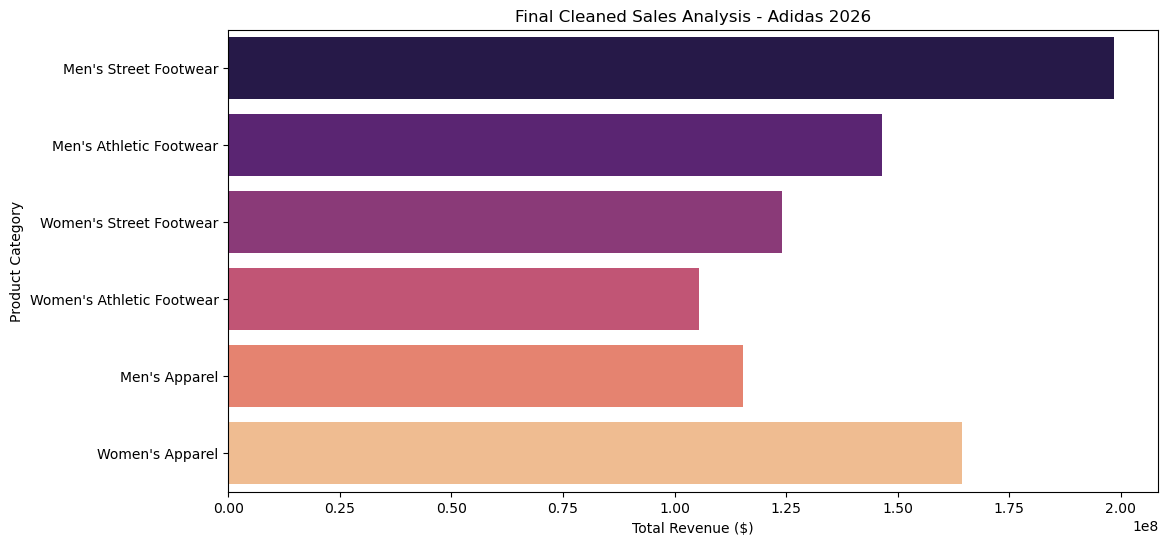

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(x='Total Sales', y='Product', data=df, estimator=sum, errorbar=None, hue='Product', palette='magma', legend=False)
plt.title('Final Cleaned Sales Analysis - Adidas 2026')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Category')
plt.show()

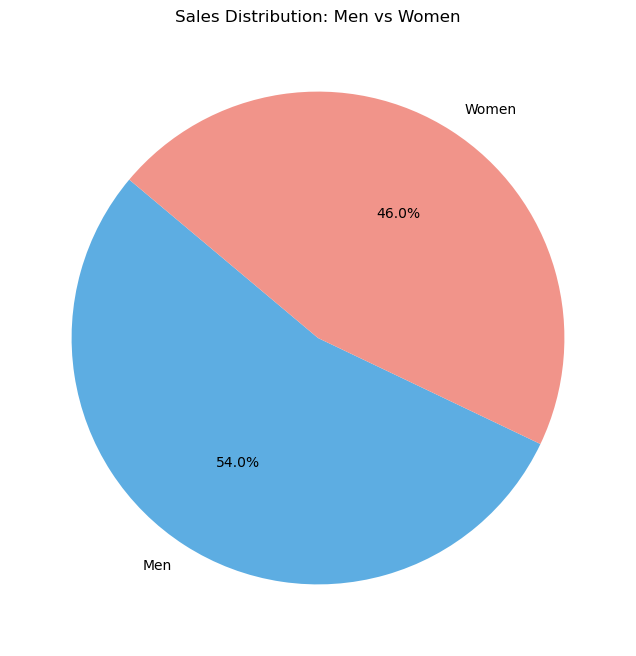

In [9]:
import matplotlib.pyplot as plt

def get_gender(product):
    if 'Men' in product:
        return 'Men'
    else:
        return 'Women'

df['Gender'] = df['Product'].apply(get_gender)
gender_sales = df.groupby('Gender')['Total Sales'].sum()

plt.figure(figsize=(8, 8))
colors = ['#5DADE2', '#F1948A'] 

plt.pie(
    gender_sales, 
    labels=gender_sales.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors
)

plt.title('Sales Distribution: Men vs Women')
plt.show()

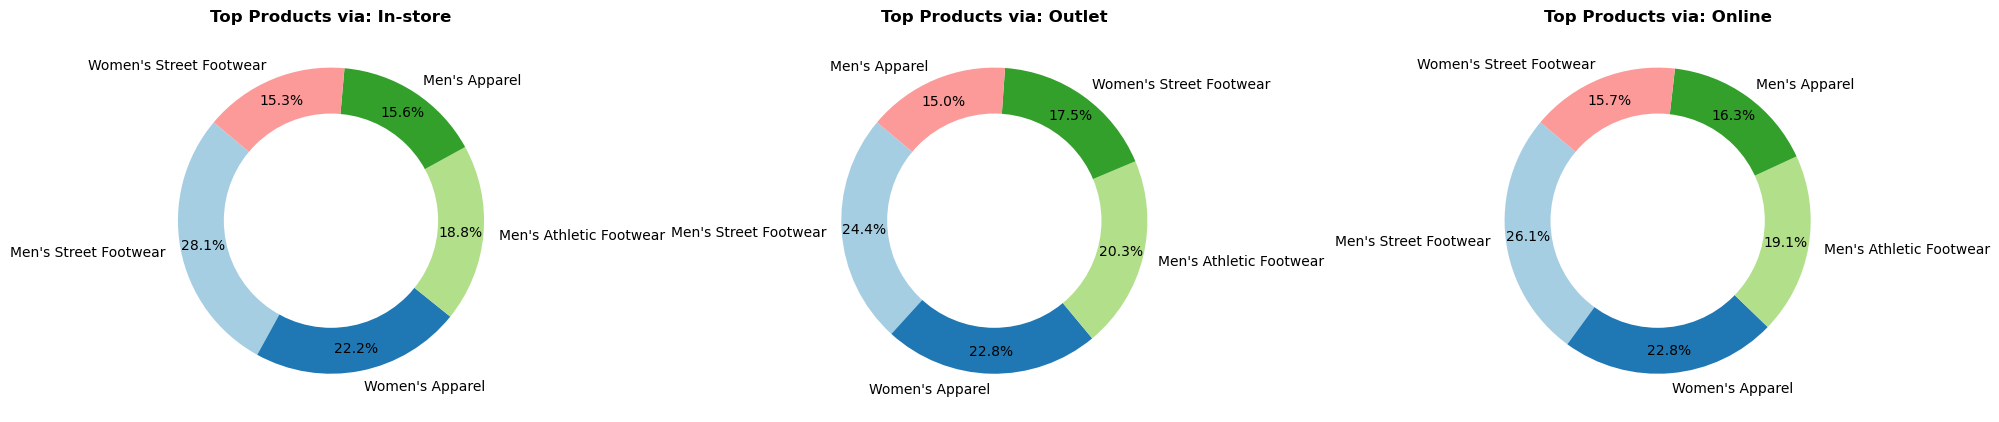

In [10]:
import matplotlib.pyplot as plt

methods = df['Sales Method'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, method in enumerate(methods):
    data = df[df['Sales Method'] == method].groupby('Product')['Total Sales'].sum().nlargest(5)
    
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', startangle=140, 
                colors=plt.cm.Paired.colors, pctdistance=0.85)
    
    # تحويل الـ Pie لـ Donut
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    axes[i].add_artist(centre_circle)
    
    axes[i].set_title(f'Top Products via: {method}', fontweight='bold')

plt.tight_layout()
plt.show()

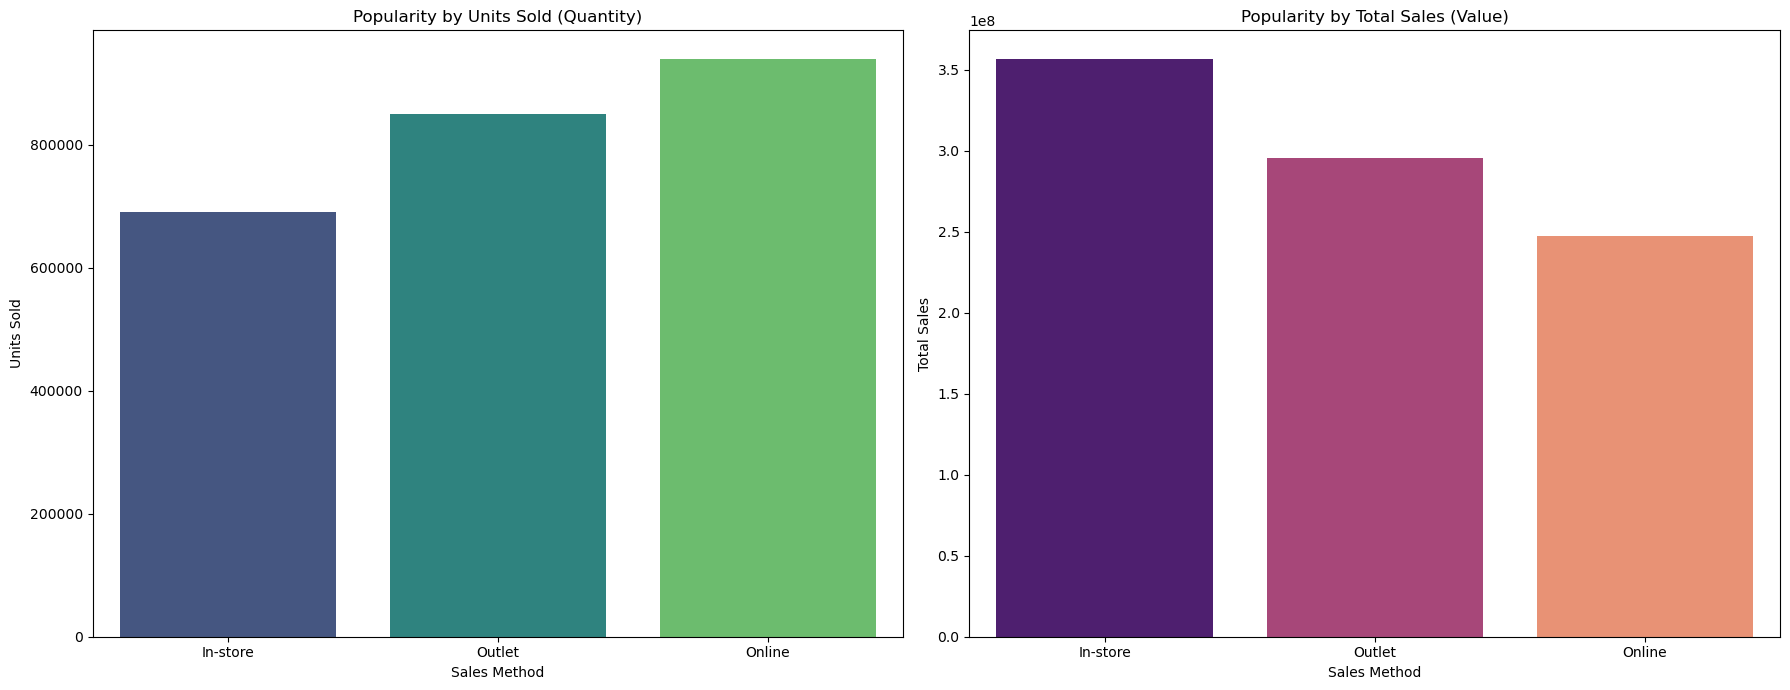

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    x='Sales Method', 
    y='Units Sold', 
    data=df, 
    estimator=sum, 
    errorbar=None, 
    ax=axes[0], 
    palette='viridis',
    hue='Sales Method',
    legend=False
)
axes[0].set_title('Popularity by Units Sold (Quantity)')

sns.barplot(
    x='Sales Method', 
    y='Total Sales', 
    data=df, 
    estimator=sum, 
    errorbar=None, 
    ax=axes[1], 
    palette='magma',
    hue='Sales Method',
    legend=False
)
axes[1].set_title('Popularity by Total Sales (Value)')

plt.tight_layout()
plt.show()

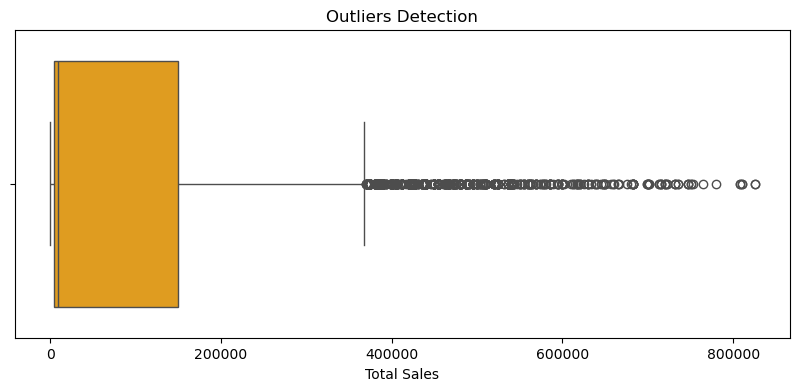

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Total Sales'], color='orange')

plt.title('Outliers Detection')
plt.xlabel('Total Sales')
plt.show()

In [6]:
!pip install scikit-learn streamlit

Defaulting to user installation because normal site-packages is not writeable


In [7]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Adidas Sales Dashboard", page_icon="👟", layout="wide")

st.title("Adidas Sales Dashboard 👟")
st.markdown("### Interactive Project Analytics & Insights")

df = pd.read_excel('Adidas Data.xlsx', skiprows=4)

st.sidebar.header("Filter Options")
sales_method = st.sidebar.multiselect(
    "Select Sales Method:",
    options=df["Sales Method"].unique(),
    default=df["Sales Method"].unique()
)

df_filtered = df[df["Sales Method"].isin(sales_method)]

col1, col2, col3 = st.columns(3)
col1.metric("Total Rows Available", len(df_filtered))
col2.metric("Total Sales ($)", f"{df_filtered['Total Sales'].sum():,.0f}")
col3.metric("Total Profit ($)", f"{df_filtered['Operating Profit'].sum():,.0f}")

st.markdown("---")

st.subheader("📊 Data Preview")
st.dataframe(df_filtered.head(10), use_container_width=True)

st.subheader("📈 Visualizations")
fig, ax = plt.subplots(figsize=(6, 4))
df_filtered['Sales Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, colors=['#ff9999','#66b3ff','#99ff99'])
ax.set_ylabel('')
st.pyplot(fig)

Writing app.py


In [8]:
%%writefile requirements.txt
pandas
openpyxl
matplotlib
scikit-learn
streamlit

Writing requirements.txt
